##### Question (a)

     n         a      f(a)         b      f(b)       mid        f(mid)  \
0    1  1.000000  0.540302  2.000000 -0.832294  1.500000  1.061058e-01   
1    2  1.500000  0.106106  2.000000 -0.832294  1.750000 -3.119306e-01   
2    3  1.500000  0.106106  1.750000 -0.311931  1.625000 -8.803784e-02   
3    4  1.500000  0.106106  1.625000 -0.088038  1.562500  1.296286e-02   
4    5  1.562500  0.012963  1.625000 -0.088038  1.593750 -3.657920e-02   
5    6  1.562500  0.012963  1.593750 -0.036579  1.578125 -1.156546e-02   
6    7  1.562500  0.012963  1.578125 -0.011565  1.570312  7.597592e-04   
7    8  1.570312  0.000760  1.578125 -0.011565  1.574219 -5.387632e-03   
8    9  1.570312  0.000760  1.574219 -0.005388  1.572266 -2.310126e-03   
9   10  1.570312  0.000760  1.572266 -0.002310  1.571289 -7.742302e-04   
10  11  1.570312  0.000760  1.571289 -0.000774  1.570801 -6.997062e-06   
11  12  1.570312  0.000760  1.570801 -0.000007  1.570557  3.764407e-04   
12  13  1.570557  0.000376  1.570801 -

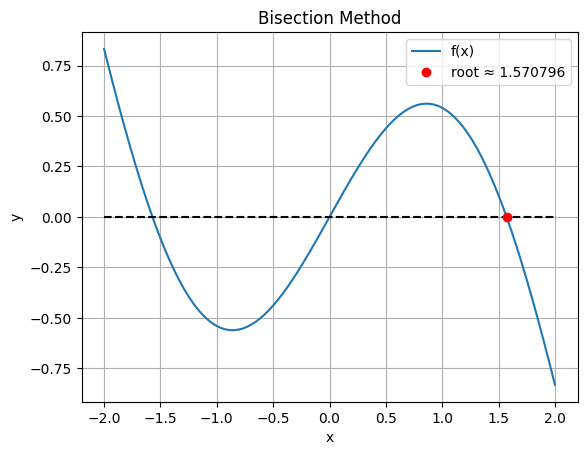

In [166]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def bisection(f, a, b, tol=1e-6, max_iter=1000):
    fa = f(a)
    fb = f(b)
    if fa * fb > 0:
        raise Exception("f(a) and f(b) must have opposite signs")
    
    table = []
    n = 0
    while abs(b - a) > tol and n < max_iter:
        n += 1
        mid = (a + b) / 2
        fm = f(mid)
        table.append([n, a, fa, b, fb, mid, fm, b-a])
        
        if fa * fm > 0:
            a, fa = mid, fm
        else:
            b, fb = mid, fm
    
    df = pd.DataFrame(table, columns=['n', 'a', 'f(a)', 'b', 'f(b)', 'mid', 'f(mid)', 'b-a'])
    print(df)
    
    return df

# function
def f(x):
    return x * np.cos(x)

# find root
df = bisection(f, 1, 2)
root = df['mid'].values[-1]
print("root =", root)

# Plot
x_domain = np.linspace(-2, 2, 400)
y = f(x_domain)

plt.plot(x_domain, y, label='f(x)')
plt.plot([-2, 2], [0, 0], color='k', linestyle='--')
plt.plot(root, f(root), 'ro', label=f"root ≈ {root:.6f}")
plt.grid()
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Bisection Method')
plt.show()



##### (b)

n    |x                   |err                 
1    |-0.0010135157984    |0.1010135157984     
2    |0.0000000010411     |0.0010135168395     
3    |0.0000000000000     |0.0000000010411     
root: 0.0


Text(0.5, 1.0, '(b)(i) Newton Raphson method')

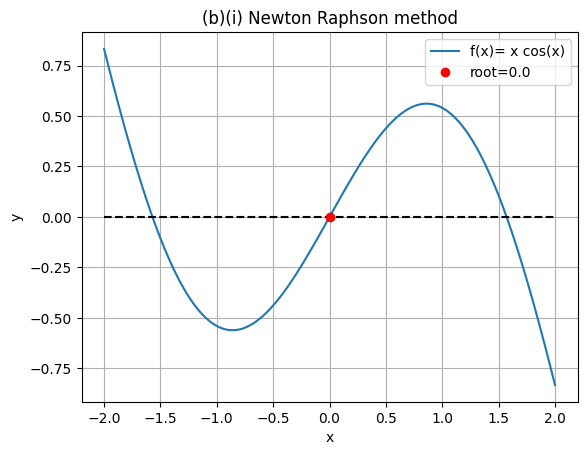

In [159]:
import numpy as np
import matplotlib.pyplot as plt

def newton_raphson(f, dfdx, x0, tol=1e-6, max_iter=100):
    x_list = []
    err_list = []

    x = x0
    for _ in range(max_iter):
        x_new = x - f(x)/dfdx(x)
        err = abs(x_new - x)
        
        x_list.append(x_new)
        err_list.append(err)
        
        if err < tol:
            break
        x = x_new

    # Tabulate
    print(f"{'n':<5}|{'x':<20}|{'err':<20}")
    
    for i in range(len(x_list)):
        print(f"{i+1:<5}|{x_list[i]:<20.13f}|{err_list[i]:<20.13f}")
    
    return x_list, err_list

# function
def f(x):
    return x * np.cos(x)

def dfdx(x):
    return np.cos(x) - x * np.sin(x)

# guess x0 = 0.1
x_list, err_list = newton_raphson(f, dfdx, 0.1)
root = x_list[-1]
print("root:", root)

# plot
x_domain = np.linspace(-2, 2, 400)
y = f(x_domain)

plt.plot(x_domain, y, label='f(x)= x cos(x)')
plt.plot([-2, 2], [0, 0], color='k', linestyle='--')
plt.plot(root, f(root), 'ro', label=f"root={root}")
plt.grid()
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('(b)(i) Newton Raphson method')


n    |x                   |err                 
1    |1.5744338194473     |0.0744338194473     
2    |1.5708046953345     |0.0036291241128     
3    |1.5707963268395     |0.0000083684950     
4    |1.5707963267949     |0.0000000000446     
root: 1.5707963267948966


Text(0.5, 1.0, 'Qb(ii) Newton Raphson method')

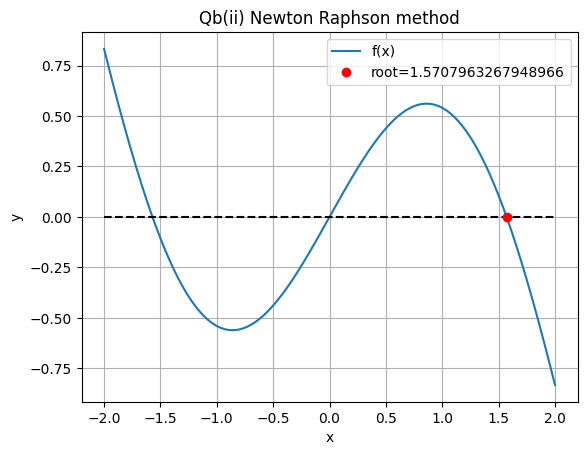

In [154]:
# Guess x0 = 1.5
x_list, err_list = newton_raphson(f, dfdx, 1.5)
root = x_list[-1]
print("root:", root)

# plot
x_domain = np.linspace(-2, 2, 400)
y = f(x_domain)

plt.plot(x_domain, y, label='f(x)')
plt.plot([-2, 2], [0, 0], color='k', linestyle='--')
plt.plot(root, f(root), 'ro', label=f"root={root}")
plt.grid()
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Qb(ii) Newton Raphson method')


n    |x                   |err                 
1    |1.6275660508126     |0.3724339491874     
2    |1.5726527073612     |0.0549133434514     
3    |1.5707985133807     |0.0018541939806     
4    |1.5707963267979     |0.0000021865827     
5    |1.5707963267949     |0.0000000000030     
root: 1.5707963267948966


Text(0.5, 1.0, 'Qb(iii) Newton Raphson method')

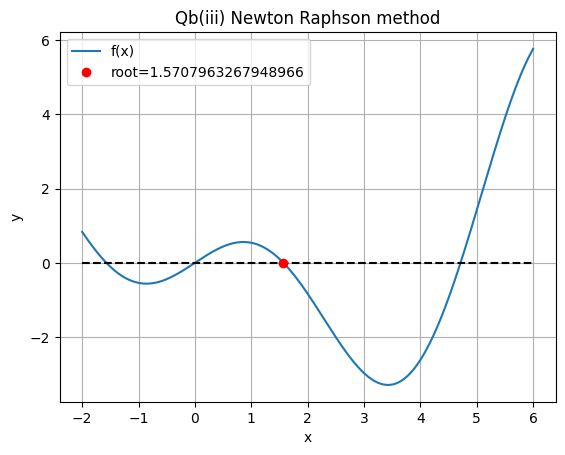

In [171]:
# New guess x0 = 2
x_list, err_list = newton_raphson(f, dfdx, 2)
root = x_list[-1]
print("root:", root)

# plot
x_domain = np.linspace(-2, 6, 400)
y = f(x_domain)

plt.plot(x_domain, y, label='f(x)')
plt.plot([-2, 6], [0, 0], color='k', linestyle='--')
plt.plot(root, f(root), 'ro', label=f"root={root}")
plt.grid()
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Qb(iii) Newton Raphson method')


n    |x                   |err                 
1    |2.0000000000000     |2.0000000000000     
2    |0.0000000000000     |2.0000000000000     
3    |0.0000000000000     |0.0000000000000     
root: 0.0


Text(0.5, 1.0, '(c) Secant method')

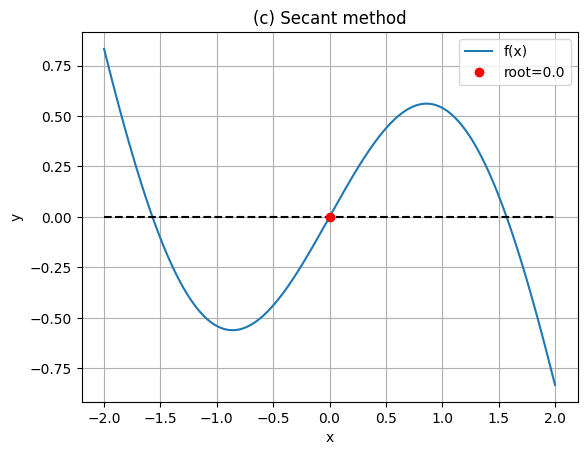

In [158]:
import numpy as np
import matplotlib.pyplot as plt

def secant(f, x0, x1, tol=1e-6, max_iter=100):
    x_list = [x0, x1]
    err_list = [abs(x1 - x0)]
    
    for _ in range(max_iter):
        x_new = x1 - f(x1) * (x1 - x0)/(f(x1) - f(x0))
        err = abs(x_new - x1)
        
        x_list.append(x_new)
        err_list.append(err)
        
        if err < tol:
            break
        
        x0 = x1
        x1 = x_new

    # Tabulate
    print(f"{'n':<5}|{'x':<20}|{'err':<20}")
    for i in range(1, len(x_list)):
        print(f"{i:<5}|{x_list[i]:<20.13f}|{err_list[i-1]:<20.13f}")
    
    return x_list, err_list

# Evaluate root
def f(x):
    return x * np.cos(x)

x_list, err_list = secant(f, 0, 2)
root = x_list[-1]
print("root:", root)

# plot
x_domain = np.linspace(-2, 2, 400)
y = f(x_domain)

plt.plot(x_domain, y, label='f(x)')
plt.plot([-2, 2], [0, 0], color='k', linestyle='--')
plt.plot(root, f(root), 'ro', label=f"root={root}")
plt.grid()
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('(c) Secant method')

n    |x                   |err                 
1    |2.0000000000000     |1.0000000000000     
2    |1.3936353553043     |0.6063646446957     
3    |1.5318002268698     |0.1381648715655     
4    |1.5761873202493     |0.0443870933795     
5    |1.5706583625882     |0.0055289576611     
6    |1.5707958555271     |0.0001374929389     
7    |1.5707963268363     |0.0000004713092     
root: 1.5707963268362937


Text(0.5, 1.0, 'Secant method')

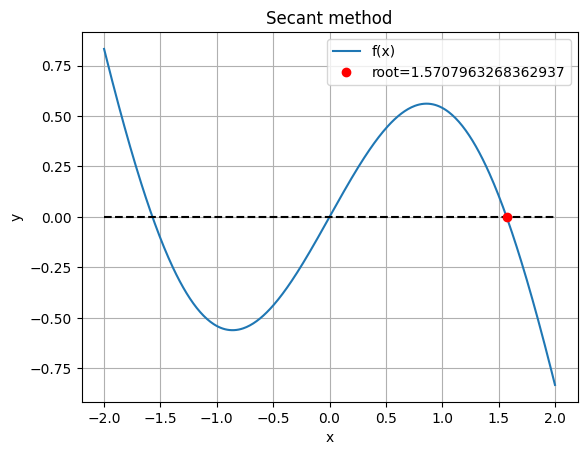

In [ ]:
# x0 =1, x1 =2
x_list, err_list = secant(f, 1, 2)
root = x_list[-1]
print("root:", root)

# plot
x_domain = np.linspace(-2, 2, 400)
y = f(x_domain)

plt.plot(x_domain, y, label='f(x)')
plt.plot([-2, 2], [0, 0], color='k', linestyle='--')
plt.plot(root, f(root), 'ro', label=f"root={root}")
plt.grid()
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Secant method')
